# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Rifky Afrizal Saputra]
- **Email:** [rifky.23266@mhs.unesa.ac.id]
- **ID Dicoding:** [CDCC284D6Y1610]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca terhadap jumlah penyewaan sepeda?
- Bulan apa yang memiliki jumlah penyewaan sepeda tertinggi?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [5]:
df = pd.read_csv("day.csv")
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset berisi data penyewaan sepeda harian
- Terdapat beberapa variabel seperti cuaca, musim, suhu dan jumlah penyewaan

### Assessing Data

In [7]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Tidak terdapat missing value yang signifikan
- Tipe data sudah cukup sesuai
- Terdapat beberapa variabel kategorikal seperti season dan weathersit

### Cleaning Data

In [8]:
df['dteday'] = pd.to_datetime(df['dteday'])

df['season'] = df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

df['weathersit'] = df['weathersit'].map({
    1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})

**Insight:**
- Kolom 'dteday' berhasil di ubah ke format datetime untuk memudahkan analisis berbasis waktu.
- Variabel kategorikal seperti 'season' dan 'weathersit' telah di ubah menjadi label yang lebih mudah dipahami.
- Tidak ditemukan missing value, sehingga tidak diperlukan proses imputasi atau penghapusan data.

## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
df.groupby("weathersit")["cnt"].mean()
df.groupby("mnth")["cnt"].sum()

,cnt
mnth,
1,134933
2,151352
3,228920
4,269094
5,331686
6,346342
7,344948
8,351194
9,345991


**Insight:**
- Cuaca cerah (Clear) memiliki rata-rata jumlah penyewaan sepeda tertinggi.
- Cuaca buruk seperti hujan ringan/salju memiliki jumlah penyewaan lebih rendah.
- Penyewaan sepeda cenderung meningkat pada bulan-bulan tertentu (indikasi pola musiman).
- Bulan dengan total penyewaan tertinggi dapat di indentifikasi dari agresi data bulanan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

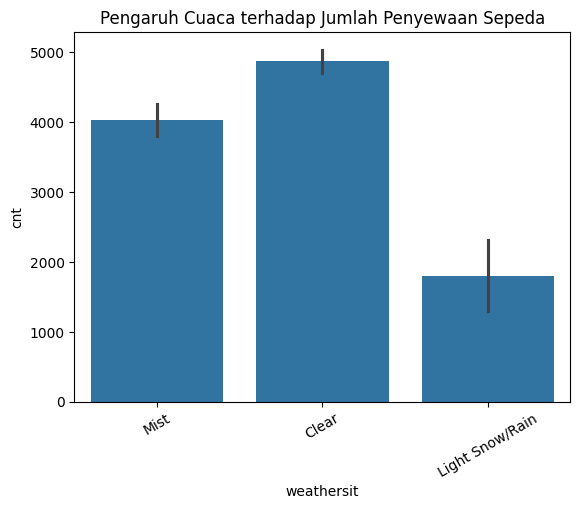

In [10]:
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Pengaruh Cuaca terhadap Jumlah Penyewaan Sepeda")
plt.xticks(rotation=30)
plt.show()

### Pertanyaan 2:

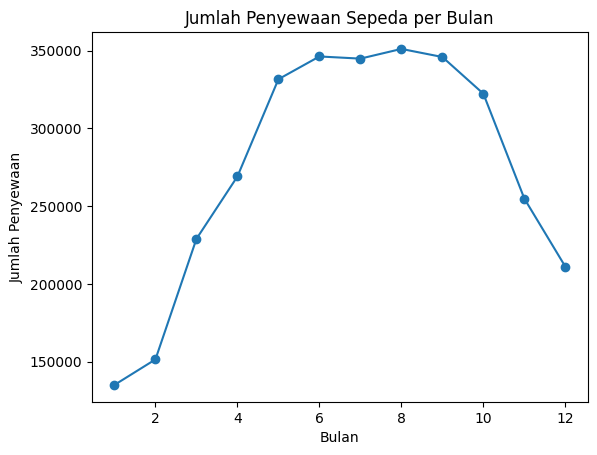

In [11]:
monthly = df.groupby("mnth")["cnt"].sum()

plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Jumlah Penyewaan Sepeda per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Penyewaan")
plt.show()

**Insight:**
- Grafik menunjukan bahwa kondisi cuaca sangat mempengaruhi jumlah penyewaan sepeda.
- Cuaca cerah mendominasi jumlah penyewaan dibandingkan kondisi lainnya.
- Tren bulanan menunjukan adanya kenaikan penyewaan di pertengahan tahun.
- Bulan dengan penyewaan tertinggi kemungkinan berada pada musim panas atau musim gugur.

## Analisis Lanjutan (Opsional)

In [12]:
df.groupby("workingday")["cnt"].mean()

,cnt
workingday,
0,4330.168831
1,4584.820000


## Conclusion

- Conclution pertanyaan 1, kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda. Cuaca cerah menghasilkan jumlah penyewaan tertinggi, sedangkan kondisi cuaca buruk seperti hujan atau salju menurunkan minat pengguna untuk menyewa sepeda.
- Conclution pertanyaan 2, jumlah penyewaan sepeda tertinggi terjadi pada bulan-bulan tertentu dipertengahan tahun, yang kemungkinan berkaitan dengan musim panas atau kondisi cuaca yang lebih mendukung aktivitas luar ruangan.